# Gaussian Mixture Model based Image Segmentation

In this work, we explore how Gaussian Mixture Model (GMM) can approximate the conditional distribution of foreground (cheetah) and background (grass). The parameters of the GMM are estimated using **Expectation-Maximization** algorithmn.

In [1]:
load("/MATLAB Drive/ECE 271A_Statistical_learning/homework5/TrainingSamplesDCT_8_new.mat")

x_cheetah_abs = TrainsampleDCT_FG;
x_grass_abs = TrainsampleDCT_BG;


In this work, we analyze the performance of **mixture of Gaussian** model under different conditions namely :

1. Initial value of $\mu_c ,\Sigma_c ,\pi_c$
2. Number of gaussian components $C$
3. Number of dimensions of space $d$

**Mixture of Gaussian**


For distributions which cannot be modelled using a single standard distribution, we can model them using sum of standard distributions. In this problem, the class conditional distribution $P_{X|Y} (x|i)$ is defined as :


$$P_{X|Y} (x|i)=\sum_{k=1}^C \pi_k G(x,\mu_k ,\Sigma_k )$$

Where $P_Z (z_k =1)=\pi_k$ and $P_{X|Z} (x|z_k =1)=G(x,\mu_k ,\Sigma_k )$ .


The obtained class conditional distribution is then multiplied by class priors and compared as per Bayesian Decision Rule


The classifier is written as a MATLAB class **mixture** 


Importing and preprocessing the image



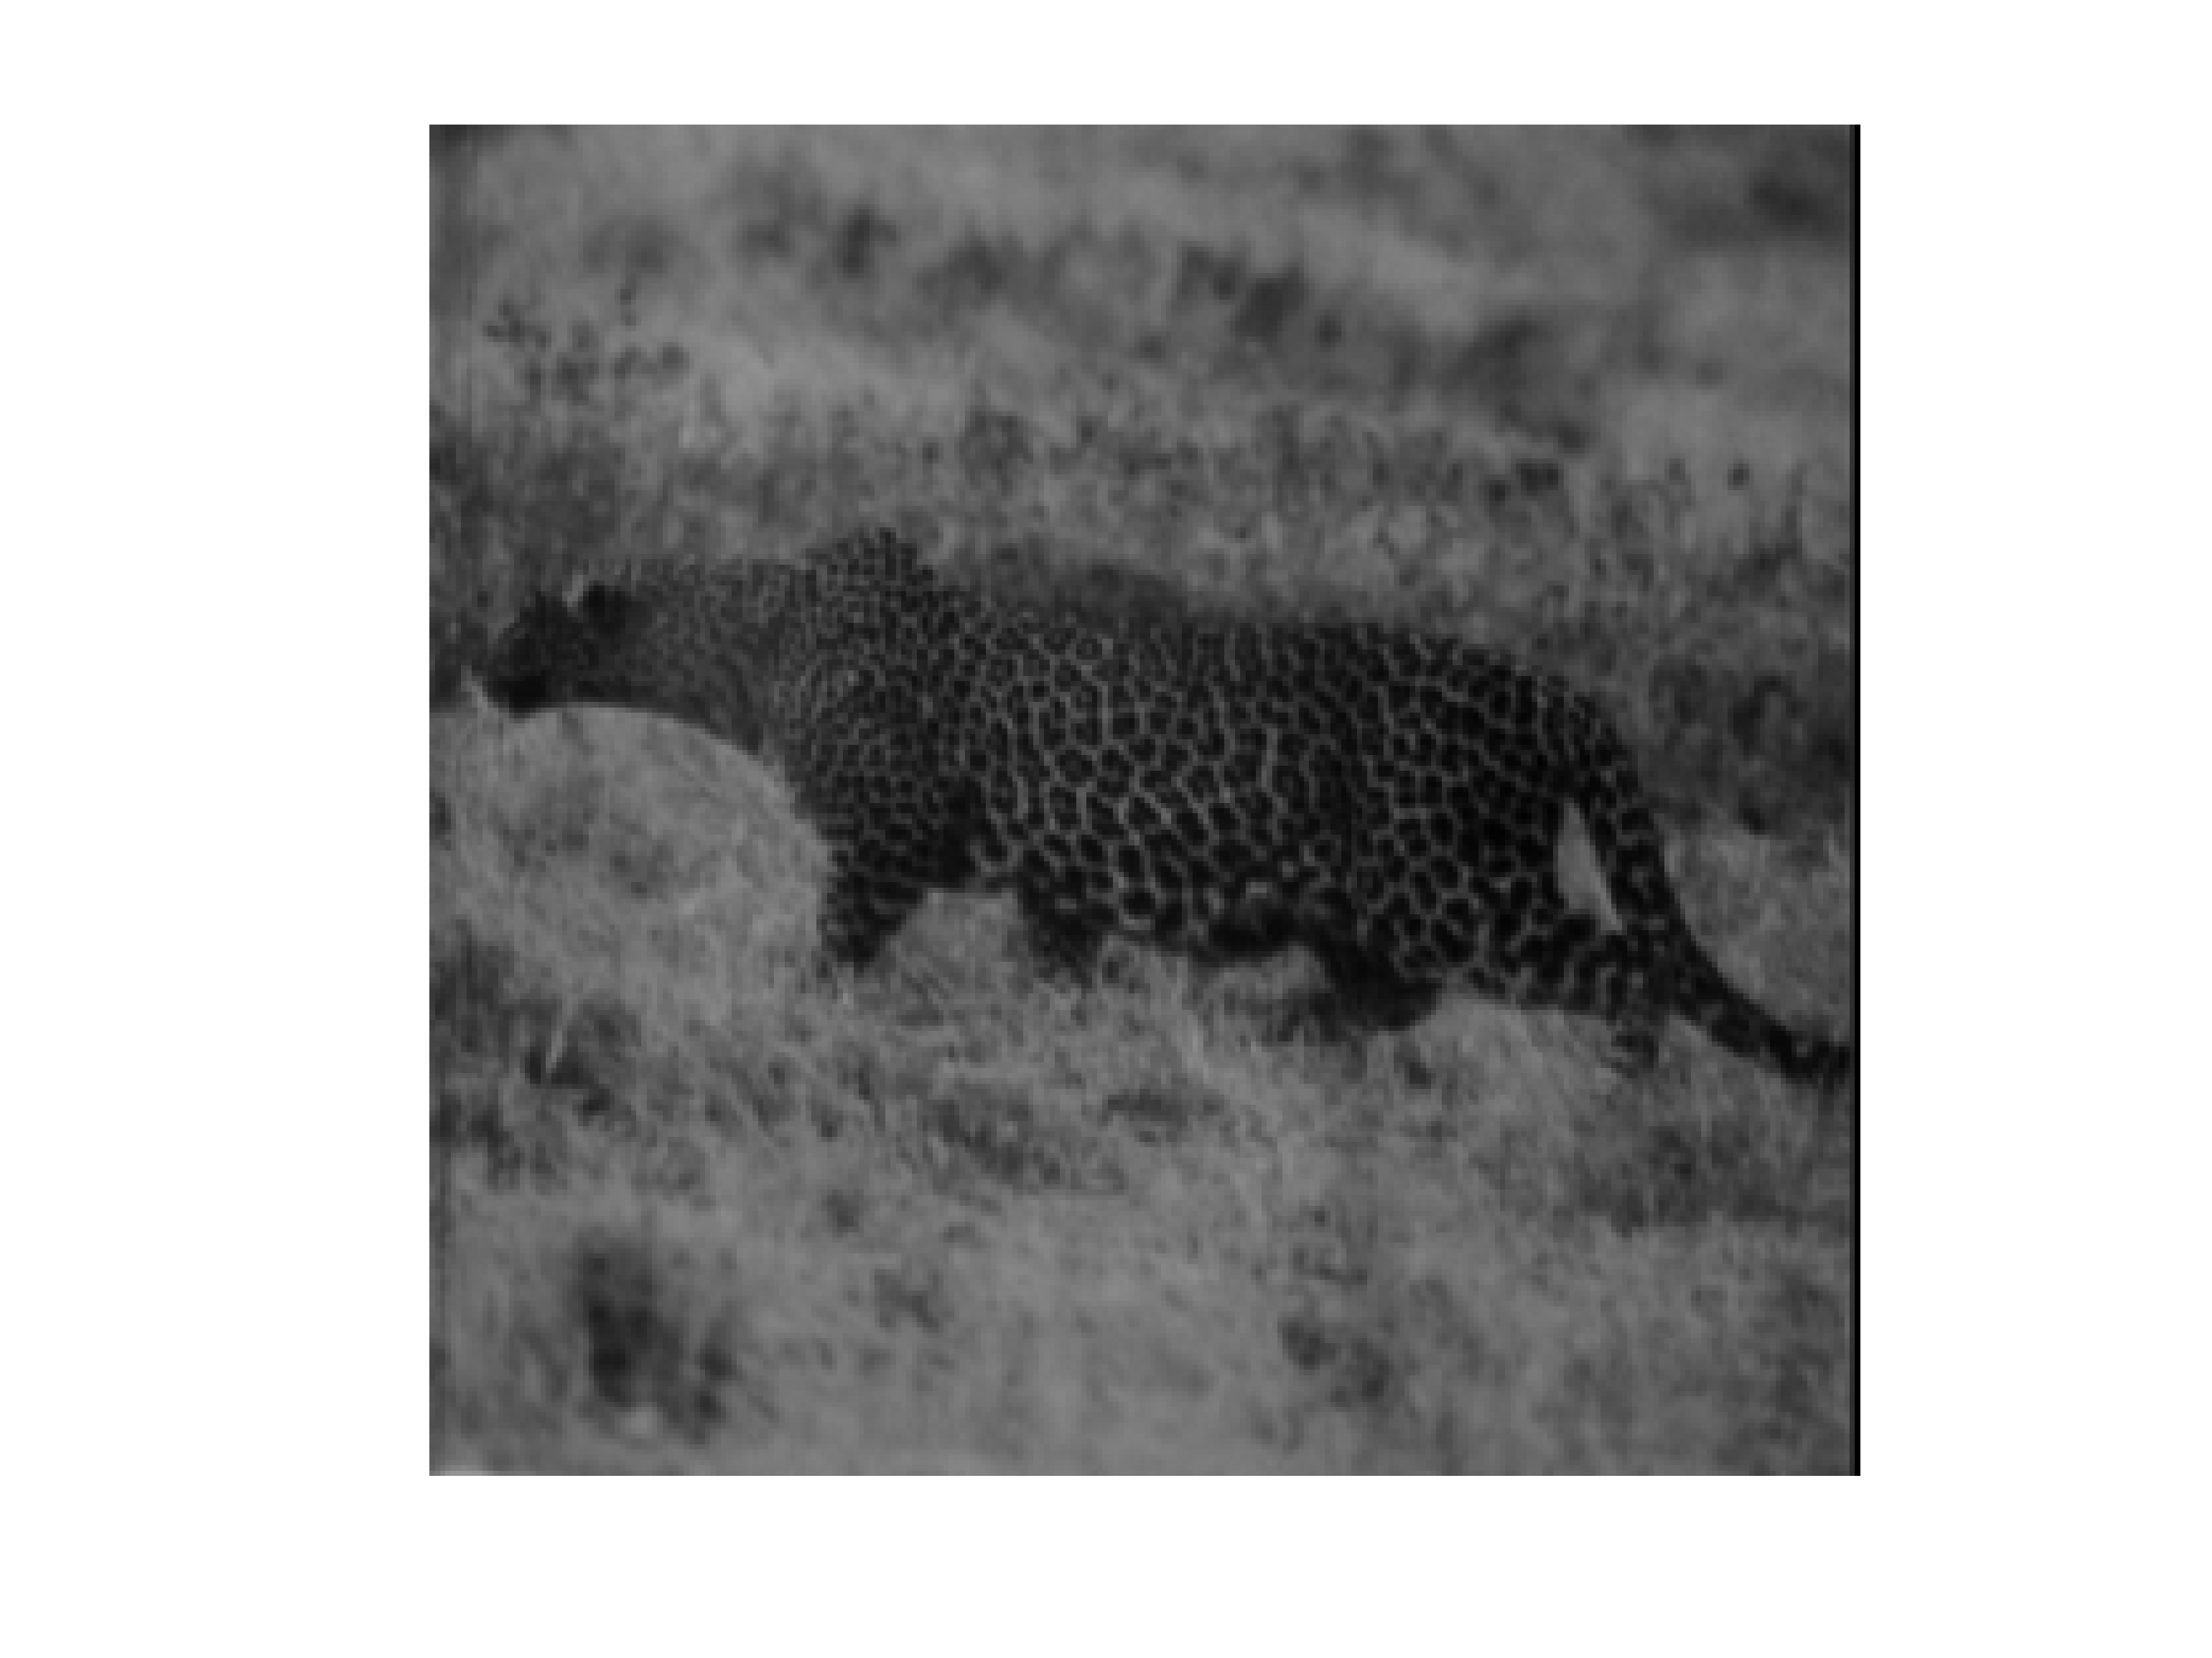

In [2]:
I = imread("cheetah.bmp");
figure
imshow(I)


Ground truth


In [3]:
I_ground = imread("cheetah_mask.bmp");
I_ground_double = im2double(I_ground);


Padding the edges of the image for sliding window


In [4]:
image = im2double(I); %255x270
win_dim = 8; % 8x8
pad_x_dir = win_dim/2;
pad_y_dir = win_dim/2;
I_pad = padarray(image,[pad_x_dir,pad_y_dir],"replicate") % 261x278 for 8x8 window with top left filter as pixel filter.

I_pad = 263x278
    0.2392    0.2392    0.2392    0.2392    0.2392    0.2353    0.2000    0.1804    0.1843    0.1882    0.1961    0.2353    0.2235    0.2392    0.2667    0.2706    0.2706    0.2784    0.3059    0.3255    0.3451    0.3686    0.3804    0.3804    0.3843    0.3686    0.3451    0.3373    0.3412    0.3529    0.3882    0.4157    0.4431    0.4471    0.4549    0.4588    0.4706    0.4784    0.4863    0.4902    0.4863    0.4863    0.4902    0.4824    0.4745    0.4863    0.4980    0.5059    0.5176    0.5294
    0.2392    0.2392    0.2392    0.2392    0.2392    0.2353    0.2000    0.1804    0.1843    0.1882    0.1961    0.2353    0.2235    0.2392    0.2667    0.2706    0.2706    0.2784    0.3059    0.3255    0.3451    0.3686    0.3804    0.3804    0.3843    0.3686    0.3451    0.3373    0.3412    0.3529    0.3882    0.4157    0.4431    0.4471    0.4549    0.4588    0.4706    0.4784    0.4863    0.4902    0.4863    0.4863    0.4902    0.4824    0.4745    0.4863    0.4980    0.5059   


DCT matrix to array \- zig zag vector


In [5]:
dct_vec_order = [1    2    6    7    15    16    28    29;
3    5    8    14    17    27    30    43;
4    9    13    18    26    31    42    44;
10    12    19    25    32    41    45    54;
11    20    24    33    40    46    53    55;
21    23    34    39    47    52    56    61;
22    35    38    48    51    57    60    62;
36    37    49    50    58    59    63    64];


Sliding window on the image and extracting the DCT matrix as array


In [6]:
k=0;
feature = ones(size(image,1)*size(image,2),win_dim*win_dim);
fl = zeros(1,win_dim*win_dim);
for i = 1:size(image,1)
    for j = 1:size(image,2)
        image_dct(i:i+win_dim-1,j:j+win_dim-1)=dct2(I_pad(i:i+win_dim-1,j:j+win_dim-1));
        k=k+1;
        fl(dct_vec_order) = image_dct(i:i+win_dim-1,j:j+win_dim-1);
        feature(k,:) = fl;
    end
end


Obtaining feature X from the flattened DCT matrix


In [7]:
X = feature;

## Part 1 : Gaussian Mixture of **8** components 

In [ ]:
% mixture(x,FG,BG,C,I_ground_double)
n = 5; % Number of trials
sol1(n) = mixture;
C = 8;

for i = 1:5
    sol1(i) = mixture(X,x_cheetah_abs,x_grass_abs,C,I_ground_double);
end

Cheetah
Number of iterations : 39 
Grass
Number of iterations : 123 
Cheetah
Number of iterations : 21 
Grass
Number of iterations : 143 
Cheetah
Number of iterations : 19 
Grass
Number of iterations : 100 
Cheetah
Number of iterations : 25 
Grass
Number of iterations : 94 
Cheetah
Number of iterations : 23 
Grass
Number of iterations : 115

### Probability of error vs dimension : for all combinations of GMM of cheetah and grass


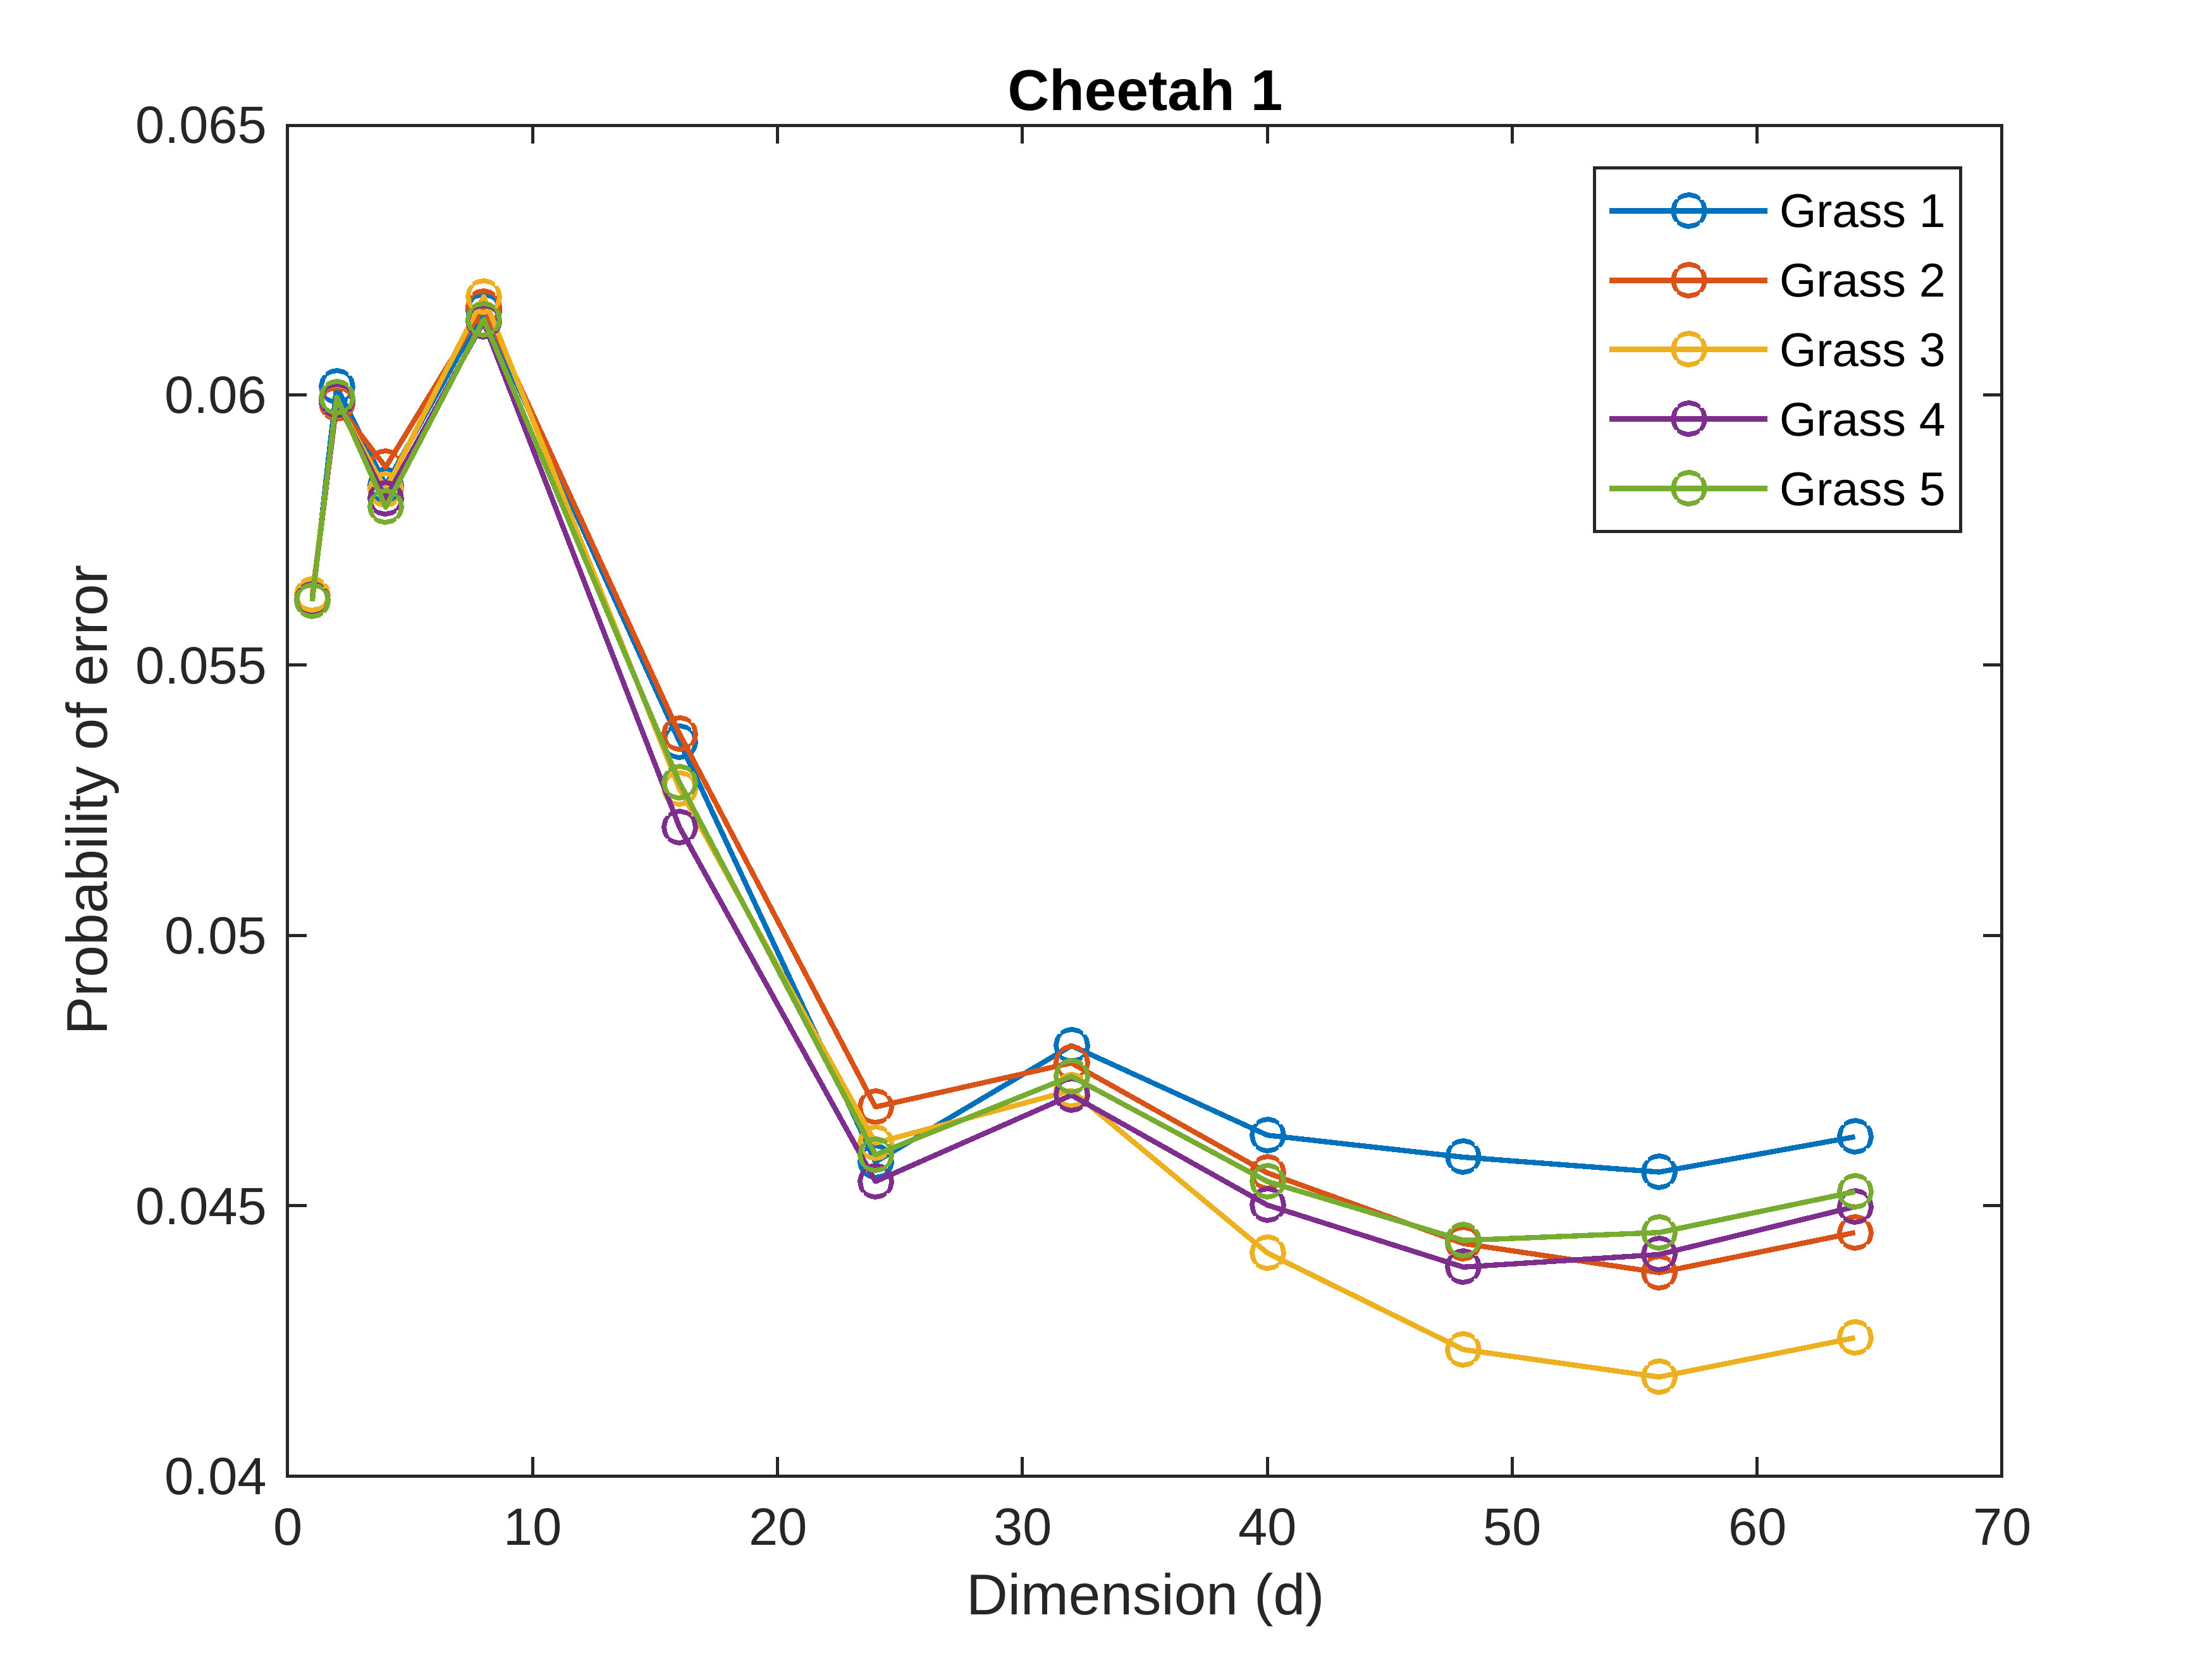


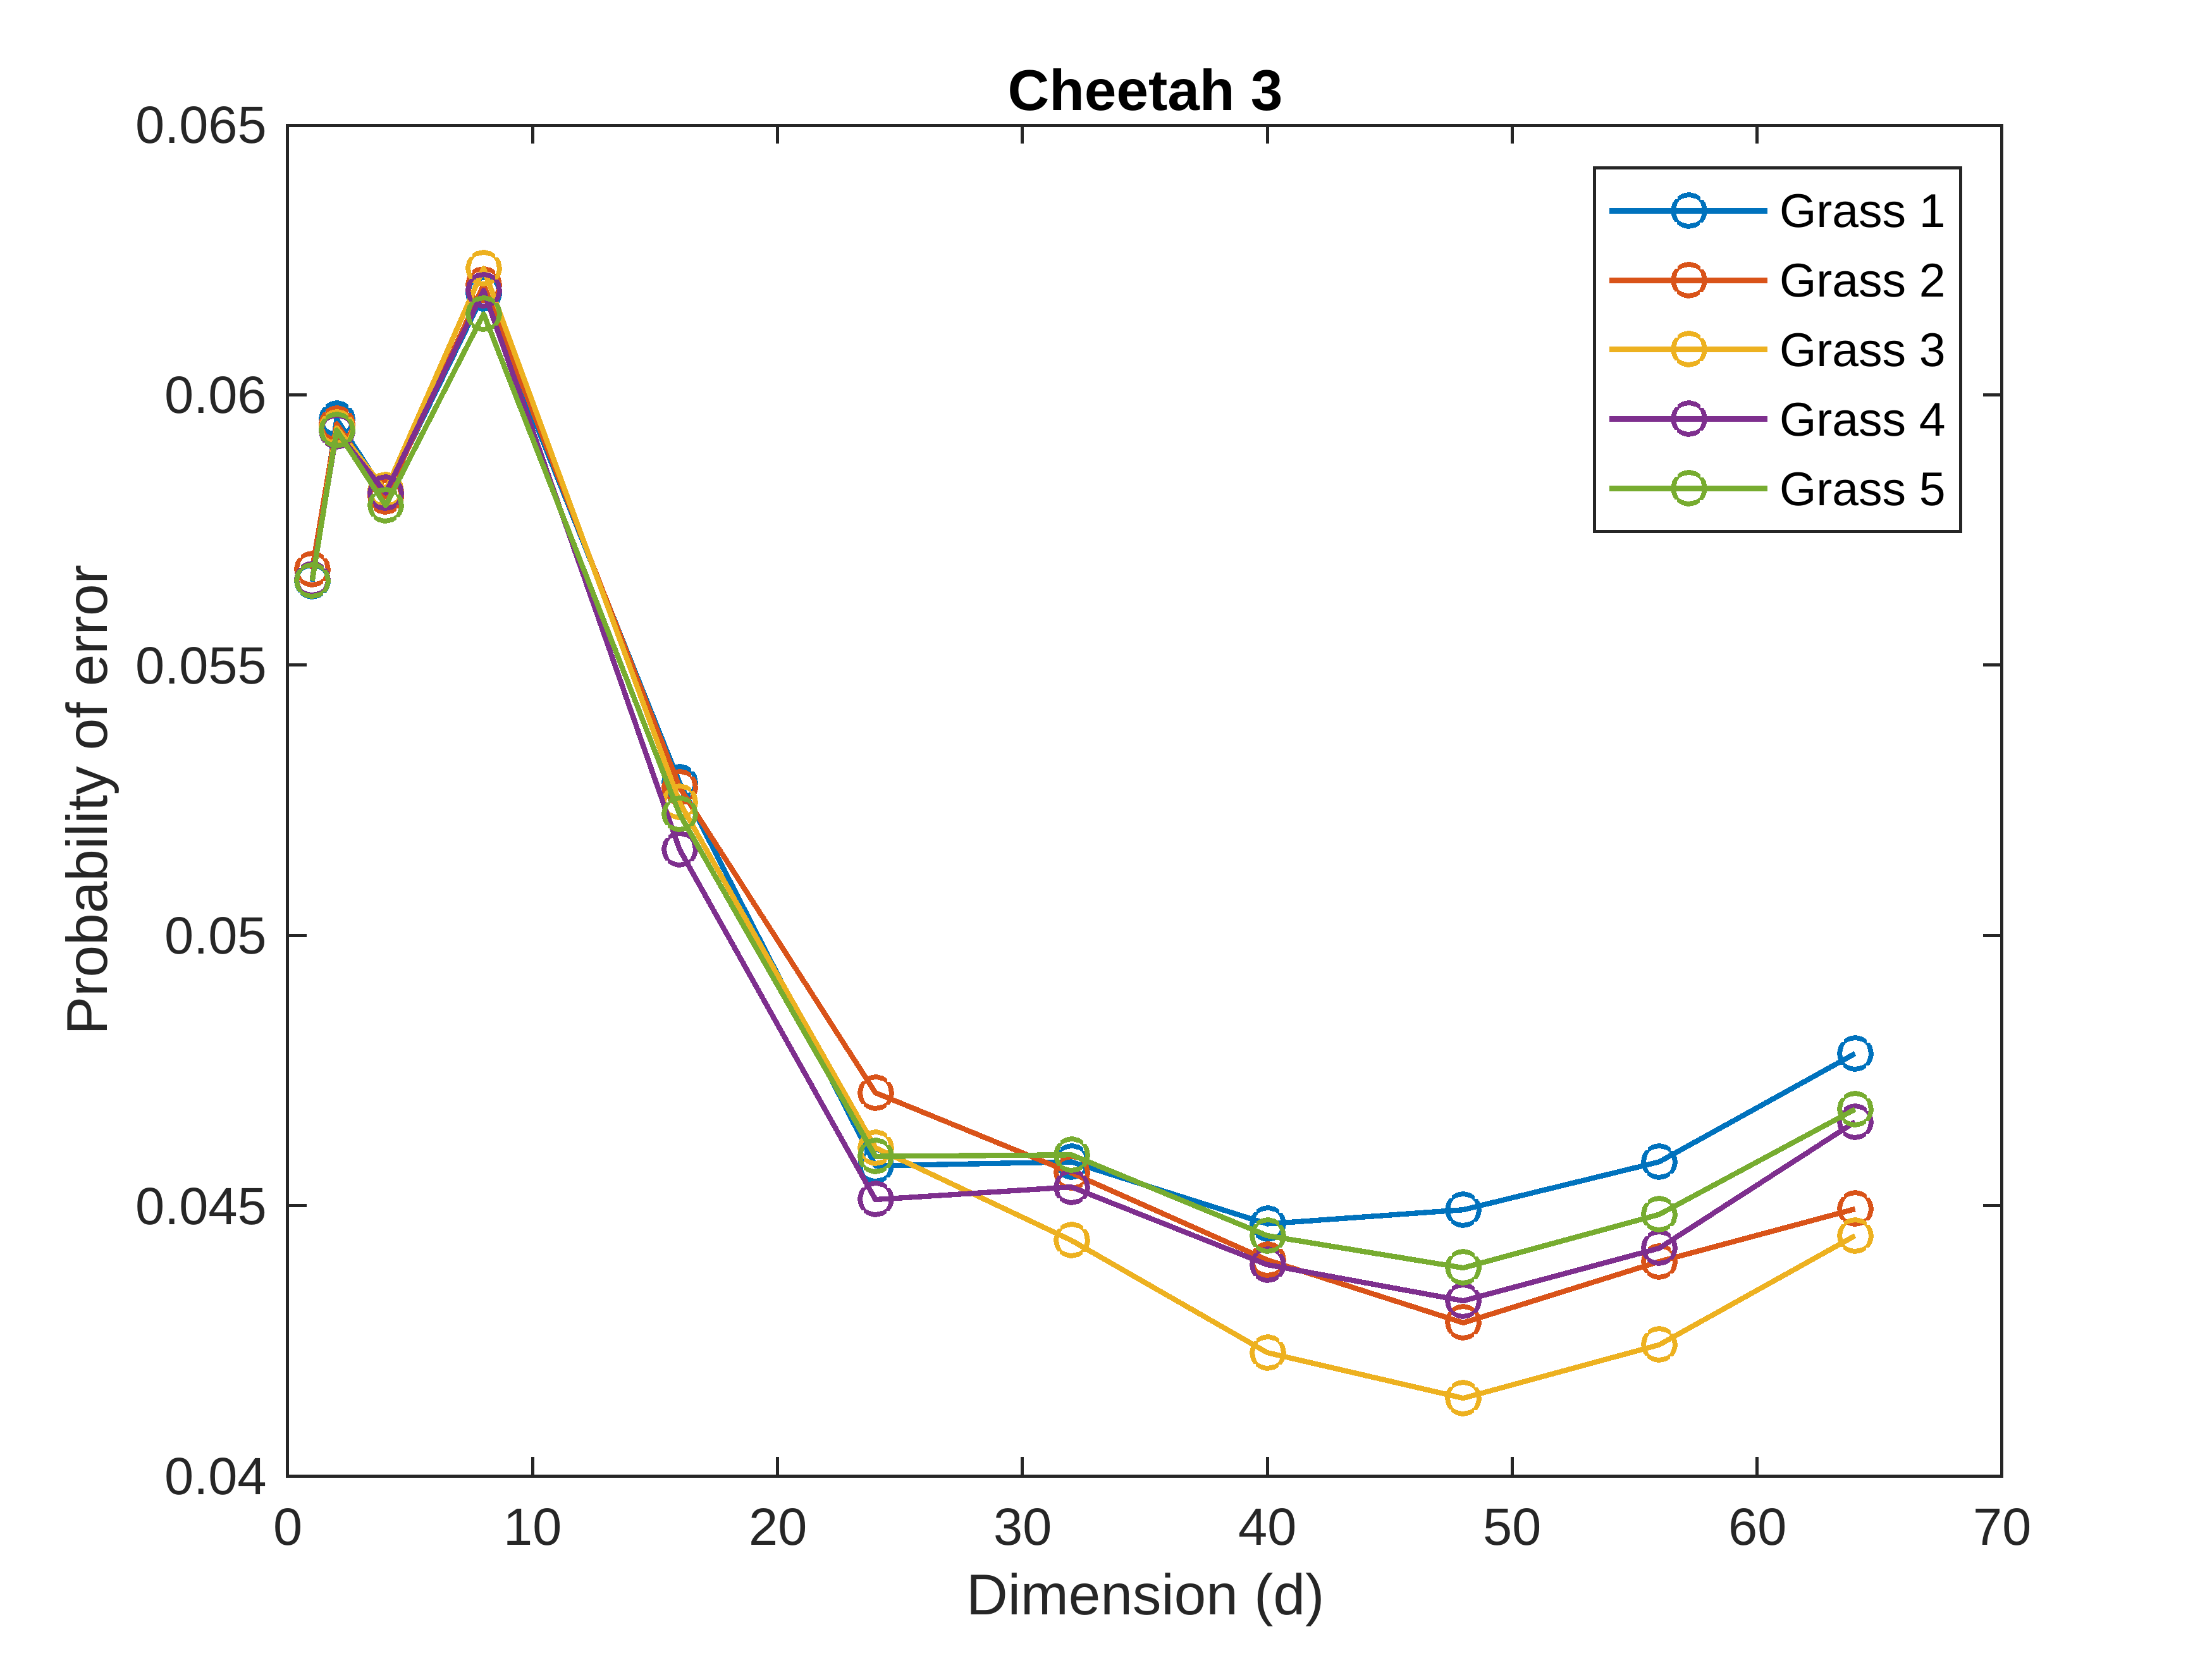

In [9]:
d = [1,2,4,8:8:64];
error = ones(n,length(d));

for i = 1:n
    figure()
    for j = 1:n
        for k = 1:length(d)
            error(j,k) = sol1(i).prediction(sol1(j),d(k));
        end
    end
    plot(d,error,'-o','LineWidth',1)
    xlabel('Dimension (d)');
    ylabel('Probability of error')
    title_str = sprintf('Cheetah %d', i);
    title(title_str);
    legend('Grass 1','Grass 2','Grass 3','Grass 4','Grass 5')
end

<center>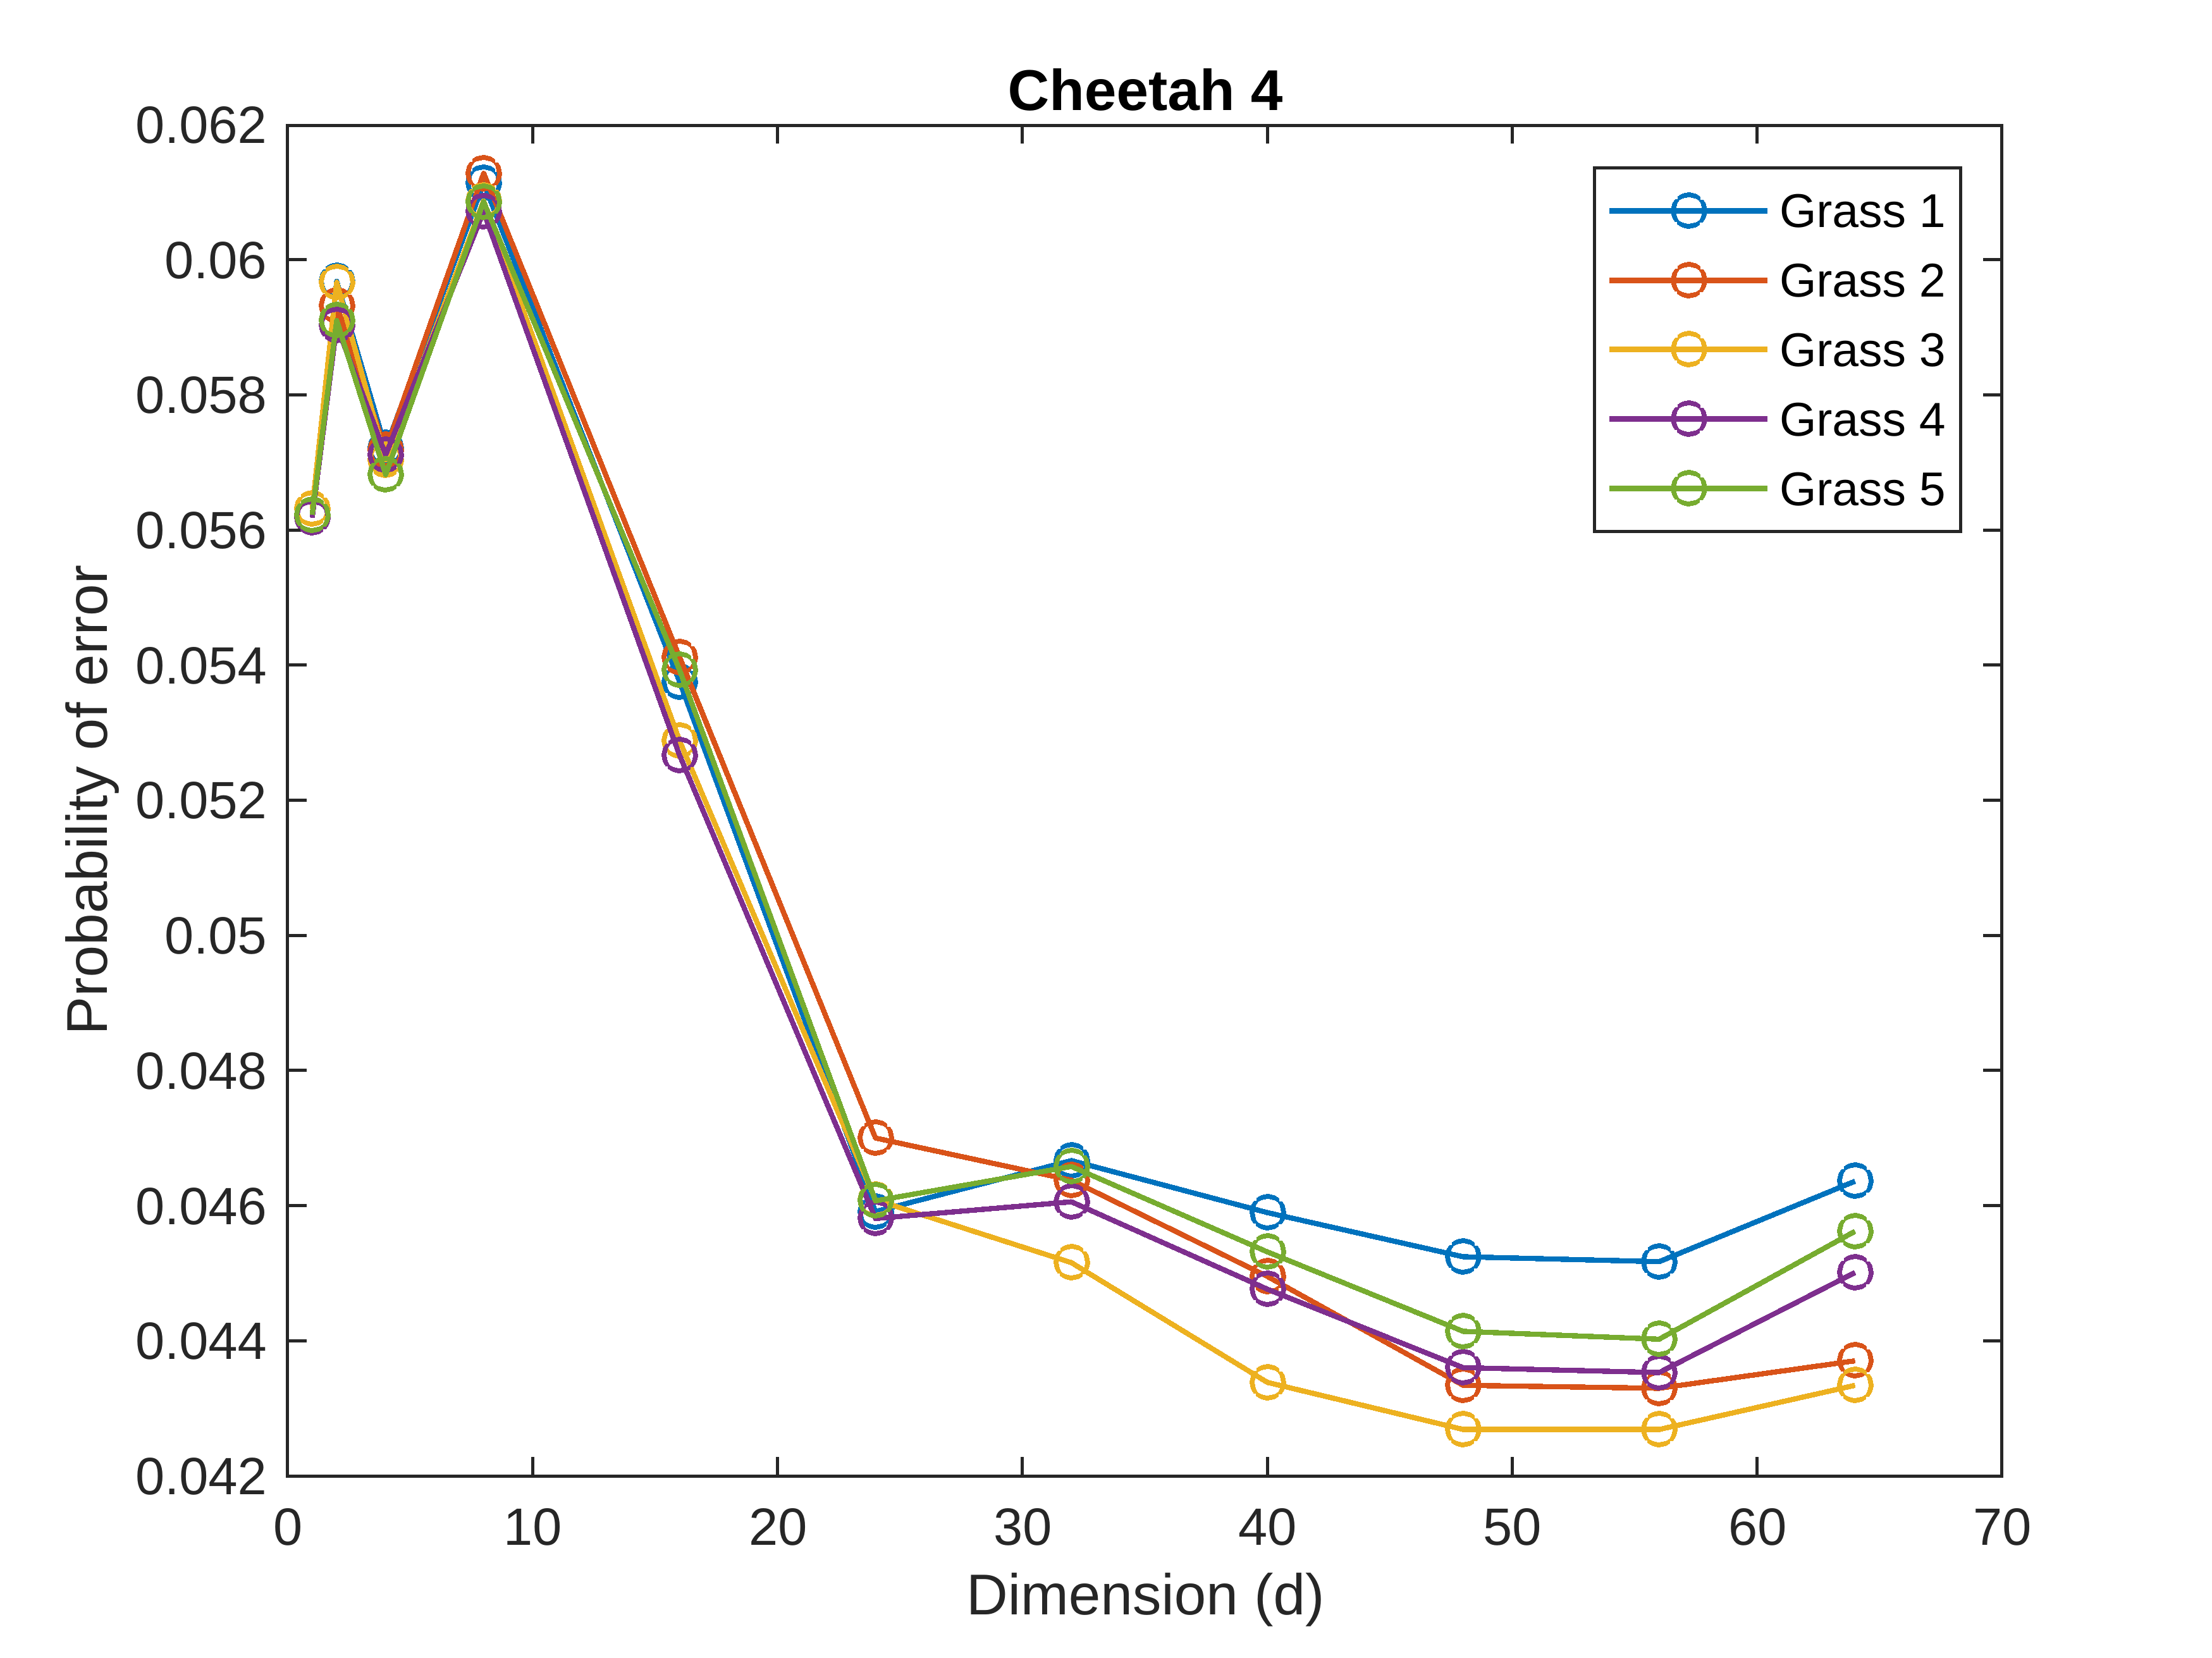</center>


<center>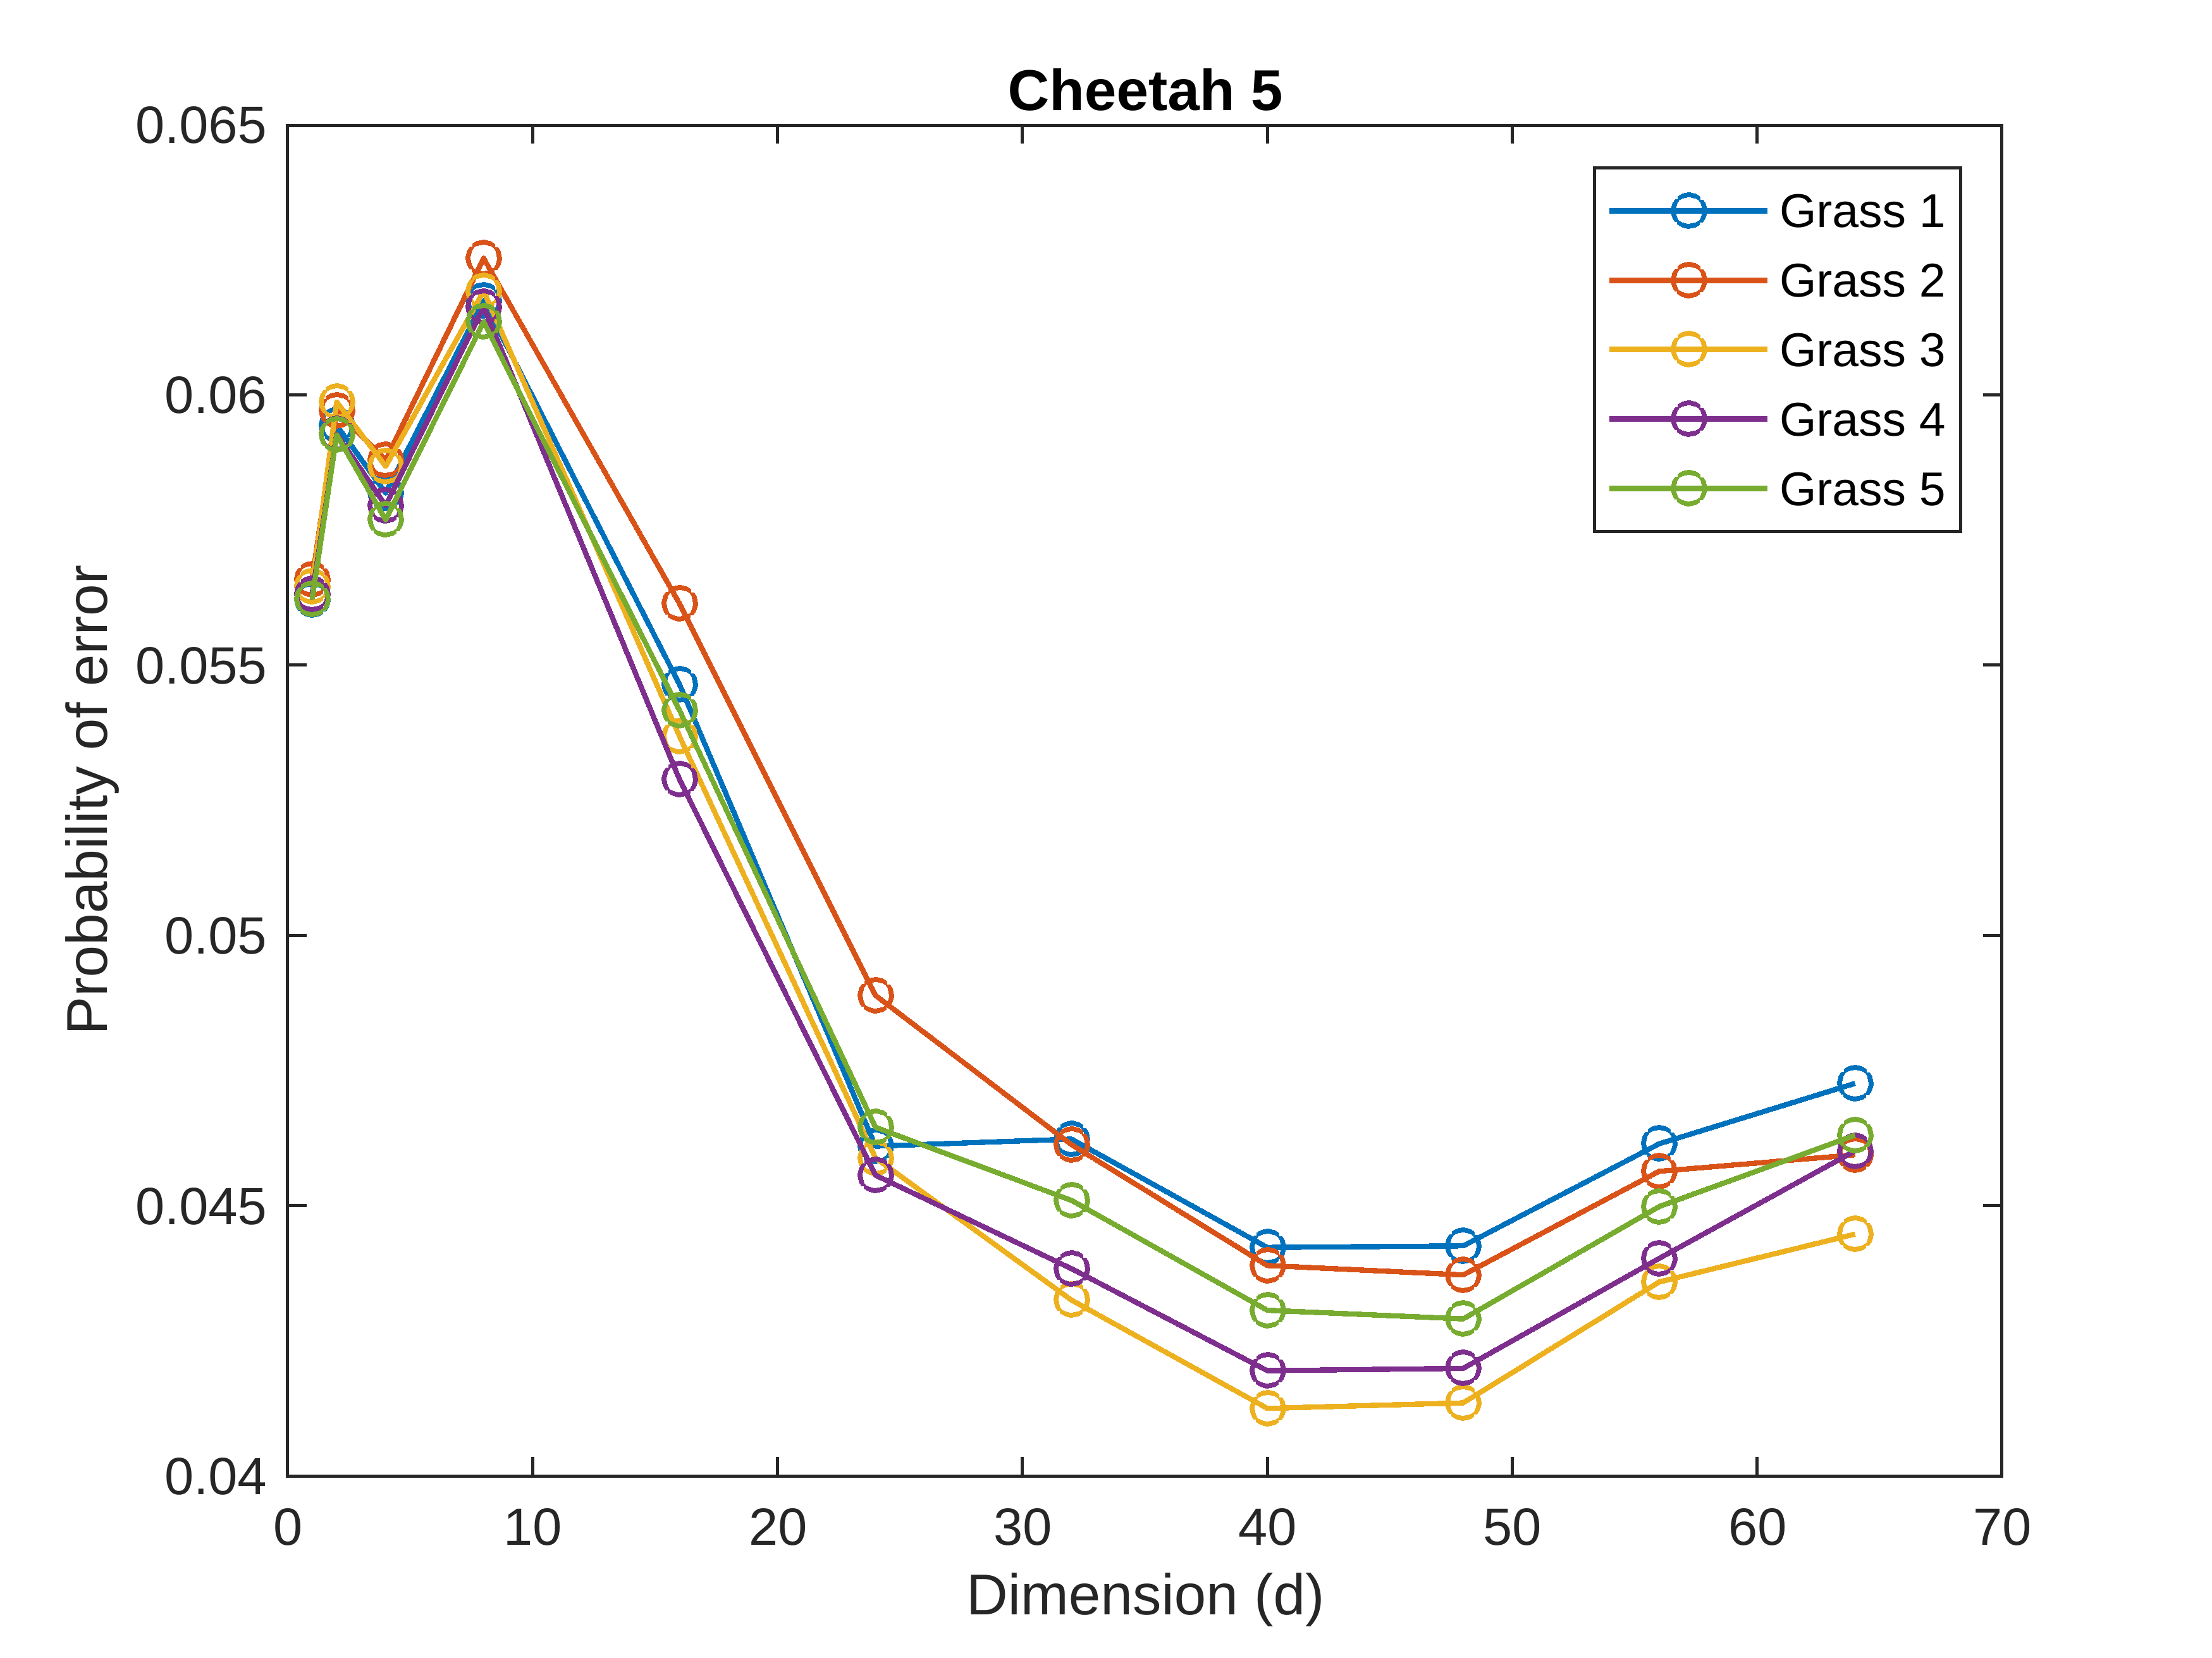</center>



As number of features increases, the error reduces depicting the capabality of GMM model in approximating the original distribution. The error remains similar irrespective of combination of GMM model uses showing the convergence of EM algorithmn irrespective of initial point. Also care must be taken during initialization as it can lead to error during convergence. 

## Part 2 : Number of components C in the mixture

In [10]:
C =2.^(0:4);
n_c = length(C);
% mixture(x,FG,BG,C,I_ground_double)

sol2(n_c) = mixture;

d = [1,2,4,8:8:64];

for i = 1:n_c
    sol2(i) = mixture(X,x_cheetah_abs,x_grass_abs,C(i),I_ground_double);
end

Cheetah
Number of iterations : 2 
Grass
Number of iterations : 2 
Cheetah
Number of iterations : 35 
Grass
Number of iterations : 22 
Cheetah
Number of iterations : 31 
Grass
Number of iterations : 28 
Cheetah
Number of iterations : 29 
Grass
Number of iterations : 62 
Cheetah
Number of iterations : 20 
Grass
Number of iterations : 90

### Probability of error vs dimension 

In [11]:
error2 = ones(n_c,length(d));

for i = 1:n_c
    for k = 1:length(d)
        error2(i,k) = sol2(i).prediction(sol2(i),d(k));
    end
end


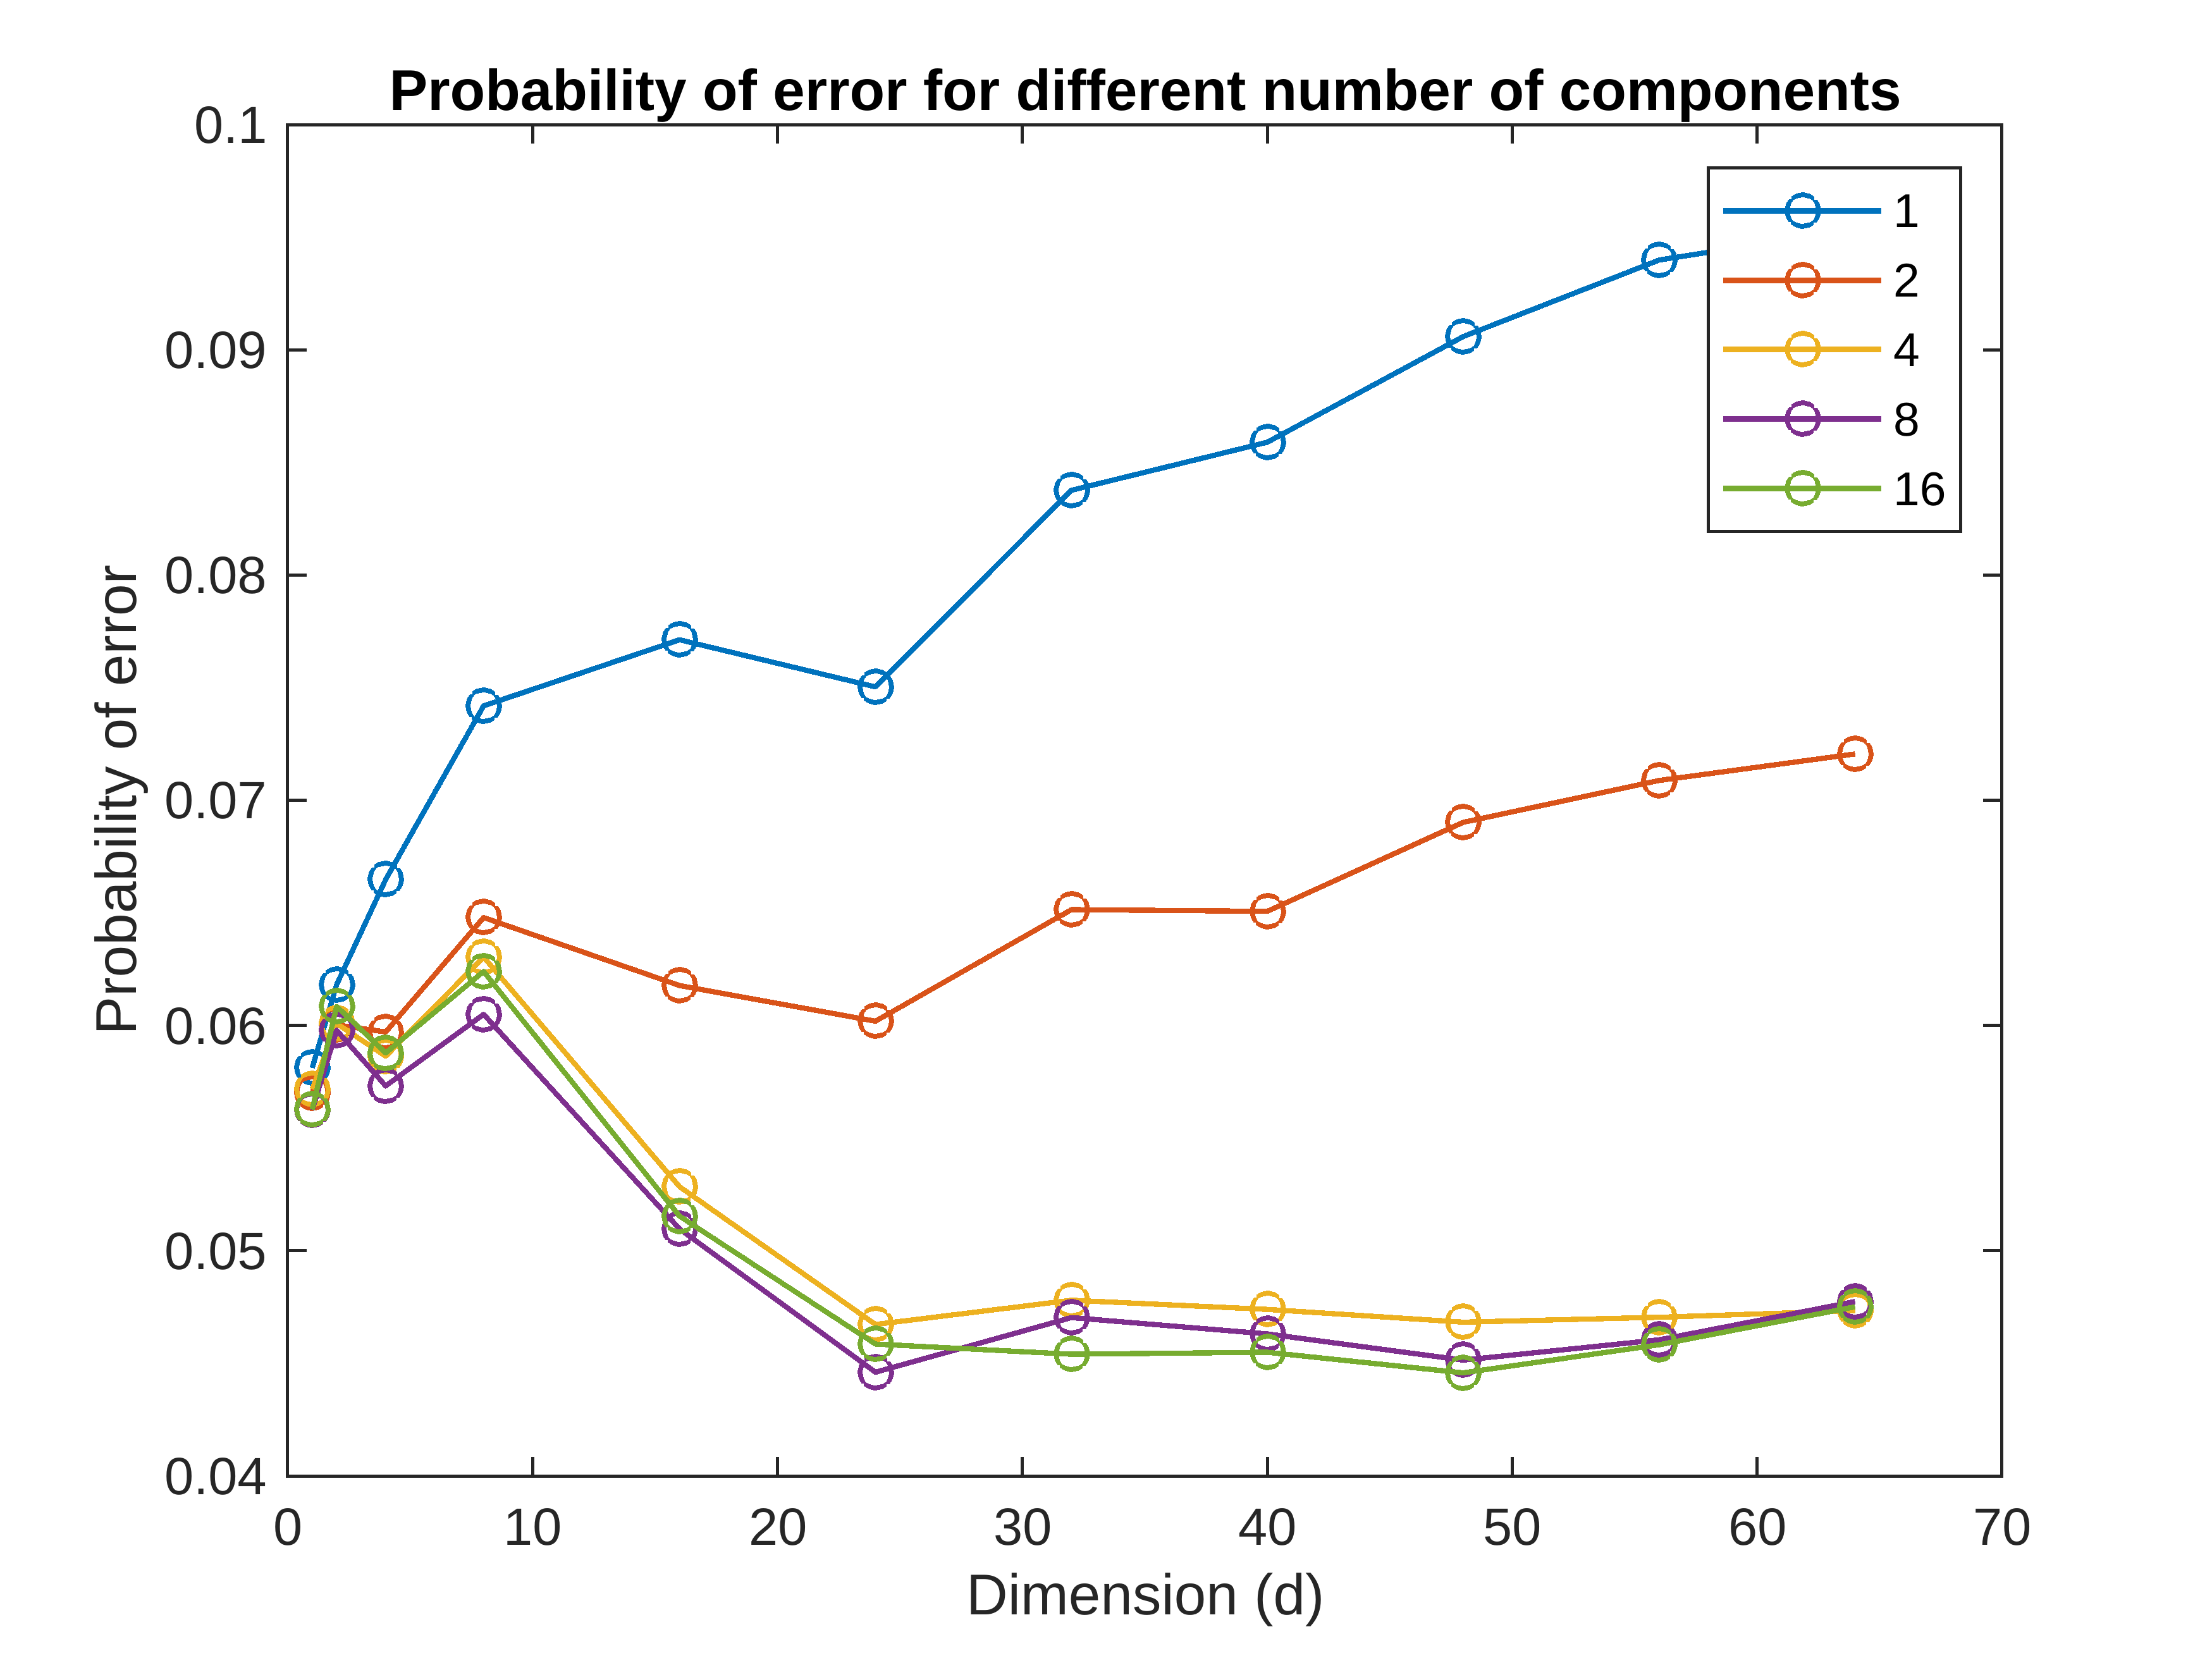

In [12]:
figure()
plot(d,error2,'-o','LineWidth',1)
xlabel('Dimension (d)');
ylabel('Probability of error')
title_str = 'Probability of error for different number of components';
title(title_str);
legend(string(C))

With increased number of components, the error reduces. For d <= 10 ,  the error seems to be similar to pure gaussian model (C = 1) while for d > 10, the benefits of using GMM over single Gaussian model is visible. Also note that  after C = 4, the performance of the model seems to be similar. Can't generalize as it depends on the underlying distribution of the data we are analyzing.